#### Predict whether the person is suffering from diabetes or not based on the diabetes dataset using Decision Tree Classifier


#### Step 1: Import all the necessary libraries

In [405]:
import  numpy             as   np
import  pandas            as   pd
import  matplotlib.pyplot as   plt
import  seaborn           as   sns
import  joblib


from    sklearn.model_selection  import  train_test_split
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.tree             import  DecisionTreeClassifier
from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report

#### Step 2: Load the Dataset

In [406]:
df = pd.read_csv('diabetes.csv')

In [407]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### OBSERVATIONS:

1.  The above dataset depicts about the diabetic condition for every patient and checks whther the patient is suffering from diabetes or not.

2.  There are total 768 records means 768 details for the diabetic patients.

3.  Inputs for the diabetic patients are from Pregnancies .... till Age. These are the independent features

4.  Output is the outcome. It is in the form of 1 or 0. 1 means the person is suffering from diabetes and 0 is non diabetic.

#### Step 3: Perform the Data Exploration

In [408]:
#### Get the total records used in the dataset

print("Total number of records used in the dataset is:", len(df))

Total number of records used in the dataset is: 768


In [409]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (768, 9)


In [410]:
#### Get the columns used in the dataset

df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [411]:
#### Get the information about the columns used in the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [412]:
#### Get the statistical summary about the columns in the dataset

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### OBSERVATIONS:

1.  The above data explains about the statistical information about every column.

In [413]:
#### get the correlation between all the numerical columns used in the dataset

df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

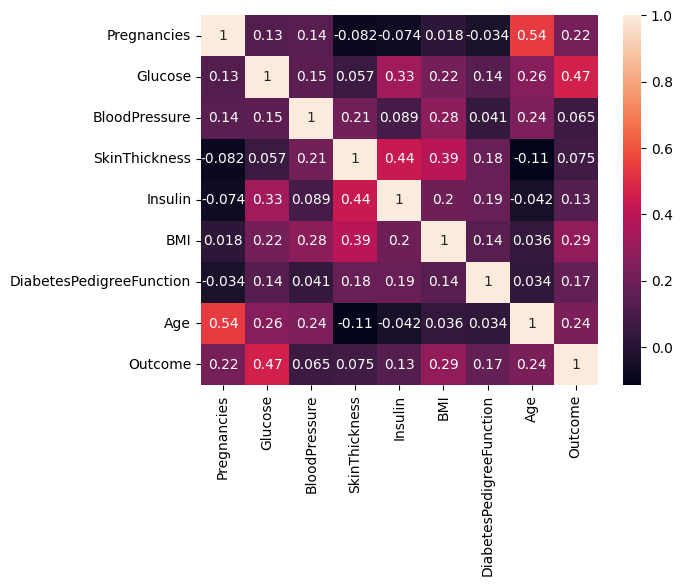

In [414]:
#### Get the graphical representation about the columns used in the dataset

sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  The above graph depicts about the graphical representation between all the numerical features used in the dataset.

2.  The higher correlation values are marked as red and the lower correlation values are marked as dark blue.

#### Step 4: Perform the Data Cleaning

In [415]:
#### Check for the NULL Values used in the dataset

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [416]:
#### Check if there are any duplicate records in the dataset

df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [417]:
#### independent variables

X = df.drop(columns='Outcome', axis=1)

print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [418]:
#### dependent varibles

Y = df['Outcome']

In [419]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


#### Step 6: Divide the independent and dependent variables into the training and testing data

In [420]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify = Y)

In [421]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,12,43,27.2,0.580,24
711,5,126,78,27,22,29.6,0.439,40
373,2,105,58,40,94,34.9,0.225,25
46,1,146,56,0,0,29.7,0.564,29
682,0,95,64,39,105,44.6,0.366,22
...,...,...,...,...,...,...,...,...
451,2,134,70,0,0,28.9,0.542,23
113,4,76,62,0,0,34.0,0.391,25
556,1,97,70,40,0,38.1,0.218,30
667,10,111,70,27,0,27.5,0.141,40


In [422]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64,0,0,27.4,0.294,40
672,10,68,106,23,49,35.5,0.285,47
700,2,122,76,27,200,35.9,0.483,26
630,7,114,64,0,0,27.4,0.732,34
81,2,74,0,0,0,0.0,0.102,22
...,...,...,...,...,...,...,...,...
32,3,88,58,11,54,24.8,0.267,22
637,2,94,76,18,66,31.6,0.649,23
593,2,82,52,22,115,28.5,1.699,25
425,4,184,78,39,277,37.0,0.264,31


In [423]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (614, 8)
Shape of the input testing  data is: (154, 8)


In [424]:
Y_train

353    0
711    0
373    0
46     0
682    0
      ..
451    1
113    0
556    0
667    1
107    0
Name: Outcome, Length: 614, dtype: int64

In [425]:
Y_test

44     0
672    0
700    0
630    1
81     0
      ..
32     0
637    0
593    0
425    1
273    0
Name: Outcome, Length: 154, dtype: int64

In [426]:
print("Shape of the output  training data is:", Y_train.shape)
print("Shape of the output  testing  data is:", Y_test.shape)

Shape of the output  training data is: (614,)
Shape of the output  testing  data is: (154,)


#### OBSERVATIONS:

1.  The dataset is divided into the training and testing data

    (a.)  The training data has 80 % data

    (b.)  The testing data  has 20 % data

#### Step 7: Perform the Standard Scaler on the inputs

In [427]:
from sklearn.preprocessing import StandardScaler

#### Create an object for Standard Scaler

sc = StandardScaler()

### using the object of standard sacler, scale the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [428]:
X_train_scaled

array([[-0.85135507, -0.98013068, -0.40478372, ..., -0.60767846,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842, ..., -0.30213902,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176, ...,  0.3725939 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.75815778,  0.03029235, ...,  0.77997981,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.31421198,  0.03029235, ..., -0.56948603,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.73223168, -0.62232176, ..., -0.31486983,
        -0.57700104,  0.30730824]], shape=(614, 8))

In [429]:
X_test_scaled

array([[ 0.96054099,  1.20788789, -0.29601471, ..., -0.58221684,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.67775979,  1.98813468, ...,  0.44897876,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.03460257,  0.3565994 , ...,  0.499902  ,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.23381399, -0.94862882, ..., -0.44217793,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.00064824,  0.46536842, ...,  0.6399409 ,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.58262854,  0.46536842, ...,  0.15617013,
        -0.16794879, -1.04589487]], shape=(154, 8))

#### OBSERVATIONS:

1.  After applying the standard scaler on the inputs, all the inputs are now in one range.

#### Step 8: Train the Decision Tree Classifier

In [430]:
from sklearn.tree import DecisionTreeClassifier

#### Create an object for Decision Tree Classifier

dectree = DecisionTreeClassifier()

#### usig the object for decision tree, train the model

dectree.fit(X_train_scaled, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

#### OBSERVATIONS:

1.  The decision tree classifier model has been trained using the training data.

#### Step 9: Predict the Model

In [431]:
Y_pred = dectree.predict(X_test_scaled)

In [432]:
Y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

#### Step 10: Evaluate the Classification Metrics

In [433]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ac = accuracy_score(Y_test, Y_pred)

print("Accuracy score of the model is:", (ac * 100.0))

Accuracy score of the model is: 70.12987012987013


In [434]:
cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", (cm))

Confusion matrix of the model is: [[85 15]
 [31 23]]


In [435]:
cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", (cr))

Classification report of the model is:               precision    recall  f1-score   support

           0       0.73      0.85      0.79       100
           1       0.61      0.43      0.50        54

    accuracy                           0.70       154
   macro avg       0.67      0.64      0.64       154
weighted avg       0.69      0.70      0.69       154



#### OBSERVATIONS:

1. Here the accuracy score of the model is 72.72 which is very high. So the model is wroking completely fine.

#### Step 11: Save and dump the model

In [436]:
import joblib

joblib.dump(sc,"Standard_dectree.pickle")

['Standard_dectree.pickle']

In [437]:
joblib.dump(dectree,"dectree_tree.pickle")

['dectree_tree.pickle']